# 🥗 PROYEK NUTRIFIRST

## Latar Belakang
NutriFirst adalah aplikasi rekomendasi menu makanan berbasis gizi dan budget. Proyek ini bertujuan untuk menganalisis data gizi dan harga menu makanan Indonesia untuk mendukung sistem rekomendasi yang cerdas.

## Tujuan Analisis
Menjawab 6 pertanyaan bisnis berikut:
1. Bagaimana distribusi harga menu berdasarkan bahan dasar (ayam, sapi, telur)?
2. Menu apa saja yang memiliki rasio protein per kalori tertinggi (efisien gizi)?
3. Bagaimana hubungan antara kandungan protein dan lemak? Apakah berbeda antar bahan dasar?
4. Menu dengan protein tinggi namun rendah lemak & karbohidrat – mana yang paling baik untuk diet?
5. Berapa rata-rata harga menu per kategori bahan dasar?
6. Apakah ada korelasi antara harga dan kandungan gizi (protein)?

## Dataset
Dataset bersumber kaggle berisi informasi gizi (kalori, protein, lemak, karbohidrat) dan harga berbagai menu makanan Indonesia.

## Persiapan Environment
1. Mengimport library yang diperlukan
2. Mengupload dataset ke Google Colab
3. Menyiapkan style visualisasi

In [54]:
# CELL CODE 1: Import Library dan Upload Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("✅ LIBRARY BERHASIL DIIMPORT")
print("="*60)

# Upload dataset
print("\n📁 SILAKAN UPLOAD FILE 'nutrition_with_price.csv'")
from google.colab import files
uploaded = files.upload()

print("\n✅ FILE BERHASIL DIUPLOAD")

✅ LIBRARY BERHASIL DIIMPORT

📁 SILAKAN UPLOAD FILE 'nutrition_with_price.csv'


Saving nutrition_with_price.csv to nutrition_with_price.csv

✅ FILE BERHASIL DIUPLOAD


## Load Dataset

Memuat data dari file CSV yang sudah diupload.

In [55]:
# CELL CODE 2: Load Dataset
df_nutrition = pd.read_csv("/content/nutrition_with_price.csv")

print("="*60)
print("📊 DATASET NUTRITION DENGAN HARGA")
print("="*60)
print(f"Shape dataset: {df_nutrition.shape}")
print("\n📷 5 DATA PERTAMA:")
display(df_nutrition.head())

📊 DATASET NUTRITION DENGAN HARGA
Shape dataset: (1346, 8)

📷 5 DATA PERTAMA:


,id,calories,proteins,fat,carbohydrate,name,image,harga
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,33832
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...,21170
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,11616
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,5272
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,9703


## Data Assessment

Memeriksa kualitas data:
- Tipe data dan informasi kolom
- Missing values
- Data duplikat
- Statistik deskriptif

In [56]:
# CELL CODE 3: Data Assessment
print("="*60)
print("🔍 DATA ASSESSMENT")
print("="*60)

print("\n1️⃣ INFO DATASET:")
df_nutrition.info()

print("\n2️⃣ MISSING VALUES:")
print(df_nutrition.isna().sum())

print("\n3️⃣ JUMLAH DATA DUPLIKAT:")
print(df_nutrition.duplicated().sum())

print("\n4️⃣ STATISTIK DESKRIPTIF:")
display(df_nutrition.describe())

print("\n✅ KESIMPULAN: Data sudah bersih, siap diproses!")

🔍 DATA ASSESSMENT

1️⃣ INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
 7   harga         1346 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 84.3+ KB

2️⃣ MISSING VALUES:
id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
harga           0
dtype: int64

3️⃣ JUMLAH DATA DUPLIKAT:
0

4️⃣ STATISTIK DESKRIPTIF:


,id,calories,proteins,fat,carbohydrate,harga
count,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000
mean,673.500000,203.217385,10.001189,7.584027,25.390193,8894.718425
std,388.701042,163.075430,11.847980,13.733063,32.193054,5522.260901
min,1.000000,0.000000,0.000000,0.000000,0.000000,1593.000000
25%,337.250000,75.000000,1.800000,0.500000,4.525000,5255.250000
50%,673.500000,146.000000,5.000000,2.000000,13.300000,7565.500000
75%,1009.750000,333.750000,15.000000,8.275000,37.575000,10827.250000
max,1346.000000,940.000000,83.000000,100.000000,647.000000,33893.000000



✅ KESIMPULAN: Data sudah bersih, siap diproses!


## Data Wrangling

Langkah-langkah:
1. Ekstrak bahan dasar dari nama menu (ayam, sapi, telur)
2. Filter hanya menu dengan bahan dasar ayam, sapi, dan telur
3. Reset index dan tambahkan kolom ID
4. Simpan data dalam berbagai format

In [57]:
# CELL CODE 4: Filtering dan Kategorisasi (VERSION FINAL - TANPA BAYAM)

print("="*60)
print("🔄 DATA WRANGLING - FILTERING & KATEGORISASI")
print("="*60)

# ========== FUNGSI EKSTRAK BAHAN DASAR ==========
def extract_bahan_dasar_baru(name):
    name_lower = str(name).lower()

    # PRIORITAS: Deteksi BAYAM dulu (agar tidak salah dikenali)
    if 'bayam' in name_lower:
        return 'lain-lain'

    # Deteksi Ayam
    elif 'ayam' in name_lower:
        return 'ayam'

    # Deteksi Telur
    elif 'telur' in name_lower:
        return 'telur'

    # Deteksi Sapi
    elif ('sapi' in name_lower or
          'daging sapi' in name_lower or
          'anak sapi' in name_lower or
          'ginjal sapi' in name_lower or
          'hati sapi' in name_lower or
          'usus sapi' in name_lower or
          'rendang sapi' in name_lower or
          'sop sapi' in name_lower or
          'sate sapi' in name_lower or
          'empal sapi' in name_lower):
        return 'sapi'

    # Selain itu
    else:
        return 'lain-lain'

# Terapkan fungsi BARU ke df_nutrition
df_nutrition['bahan_dasar'] = df_nutrition['name'].apply(extract_bahan_dasar_baru)

# Tampilkan distribusi baru
print("\n📊 DISTRIBUSI BAHAN DASAR (SETELAH PERBAIKAN):")
print(df_nutrition['bahan_dasar'].value_counts())

# Filter ulang
df_filtered = df_nutrition[df_nutrition['bahan_dasar'].isin(['sapi', 'ayam', 'telur'])].copy()

print(f"\n📊 HASIL FILTERING ULANG:")
print(f"   • Total menu setelah filtering: {len(df_filtered)}")
print(f"   • Menu sapi: {len(df_filtered[df_filtered['bahan_dasar']=='sapi'])}")
print(f"   • Menu ayam: {len(df_filtered[df_filtered['bahan_dasar']=='ayam'])}")
print(f"   • Menu telur: {len(df_filtered[df_filtered['bahan_dasar']=='telur'])}")

# Reset index
df_filtered = df_filtered.reset_index(drop=True)
df_filtered['id'] = df_filtered.index + 1

# Hitung protein per 100 kalori
df_filtered['protein_per_100cal'] = (df_filtered['proteins'] / df_filtered['calories']) * 100
df_filtered['protein_per_100cal'] = df_filtered['protein_per_100cal'].fillna(0)

# Verifikasi bayam
bayam_check = df_filtered[df_filtered['name'].str.contains('bayam', case=False, na=False)]
if len(bayam_check) == 0:
    print("\n✅ VERIFIKASI BERHASIL: Tidak ada data bayam di df_filtered!")
else:
    print(f"\n⚠️ PERINGATAN: Masih ada {len(bayam_check)} data bayam!")

print("\n📷 PREVIEW DATA SETELAH PERBAIKAN:")
display(df_filtered[['id', 'name', 'bahan_dasar']].head(20))

🔄 DATA WRANGLING - FILTERING & KATEGORISASI

📊 DISTRIBUSI BAHAN DASAR (SETELAH PERBAIKAN):
bahan_dasar
lain-lain    1267
sapi           35
ayam           28
telur          16
Name: count, dtype: int64

📊 HASIL FILTERING ULANG:
   • Total menu setelah filtering: 79
   • Menu sapi: 35
   • Menu ayam: 28
   • Menu telur: 16

✅ VERIFIKASI BERHASIL: Tidak ada data bayam di df_filtered!

📷 PREVIEW DATA SETELAH PERBAIKAN:


,id,name,bahan_dasar
0,1,Anak sapi daging gemuk segar,sapi
1,2,Anak sapi daging kurus segar,sapi
2,3,Anak sapi daging sedang segar,sapi
3,4,Ayam,ayam
4,5,Ayam goreng Kentuckysayap,ayam
5,6,Ayam ampela goreng,ayam
6,7,Ayam dideh/darah segar,ayam
7,8,Ayam goreng church texa sayap,ayam
8,9,Ayam goreng church texas dada,ayam
9,10,Ayam goreng kalasan paha,ayam


## Verifikasi Data Filtered

Memastikan data sudah siap untuk analisis lebih lanjut.

In [58]:
# CELL CODE 5: Verifikasi Data Filtered
print("="*60)
print("✅ VERIFIKASI DATA FILTERED")
print("="*60)

print(f"\n📊 INFORMASI DATASET:")
print(f"   • Total menu: {len(df_filtered)}")
print(f"   • Menu sapi: {len(df_filtered[df_filtered['bahan_dasar']=='sapi'])}")
print(f"   • Menu ayam: {len(df_filtered[df_filtered['bahan_dasar']=='ayam'])}")
print(f"   • Menu telur: {len(df_filtered[df_filtered['bahan_dasar']=='telur'])}")

print(f"\n💰 INFORMASI HARGA:")
print(f"   • Harga terendah: Rp {df_filtered['harga'].min():,.0f}")
print(f"   • Harga tertinggi: Rp {df_filtered['harga'].max():,.0f}")
print(f"   • Rata-rata harga: Rp {df_filtered['harga'].mean():,.0f}")

print("\n📷 5 DATA PERTAMA:")
display(df_filtered.head())

✅ VERIFIKASI DATA FILTERED

📊 INFORMASI DATASET:
   • Total menu: 79
   • Menu sapi: 35
   • Menu ayam: 28
   • Menu telur: 16

💰 INFORMASI HARGA:
   • Harga terendah: Rp 5,630
   • Harga tertinggi: Rp 33,489
   • Rata-rata harga: Rp 18,189

📷 5 DATA PERTAMA:


,id,calories,proteins,fat,carbohydrate,name,image,harga,bahan_dasar,protein_per_100cal
0,1,184.0,18.8,14.0,0.0,Anak sapi daging gemuk segar,https://png.pngtree.com/png-clipart/20220124/o...,33489,sapi,10.217391
1,2,174.0,19.6,10.0,0.0,Anak sapi daging kurus segar,https://asset.kompas.com/crops/BzqLdMzV0nYuuT_...,24997,sapi,11.264368
2,3,190.0,19.1,12.0,0.0,Anak sapi daging sedang segar,https://koran-jakarta.com/images/article/tips-...,17991,sapi,10.052632
3,4,302.0,18.2,25.0,0.0,Ayam,https://images.ctfassets.net/1cj2ge3ast5f/4ETq...,10758,ayam,6.026490
4,5,297.0,35.9,15.2,1.6,Ayam goreng Kentuckysayap,https://img-global.cpcdn.com/recipes/2ecb088a4...,16705,ayam,12.087542


## 📊 ANALISIS PERTANYAAN BISNIS 1 & 2

### Pertanyaan 1: Distribusi Harga Menu per Bahan Dasar
### Pertanyaan 2: Menu dengan Rasio Protein per Kalori Tertinggi

📊 PERTANYAAN 1: Distribusi Harga per Bahan Dasar
📊 PERTANYAAN 2: Menu dengan Rasio Protein per Kalori Tertinggi

----------------------------------------
PERTANYAAN 1: Distribusi Harga per Bahan Dasar
----------------------------------------


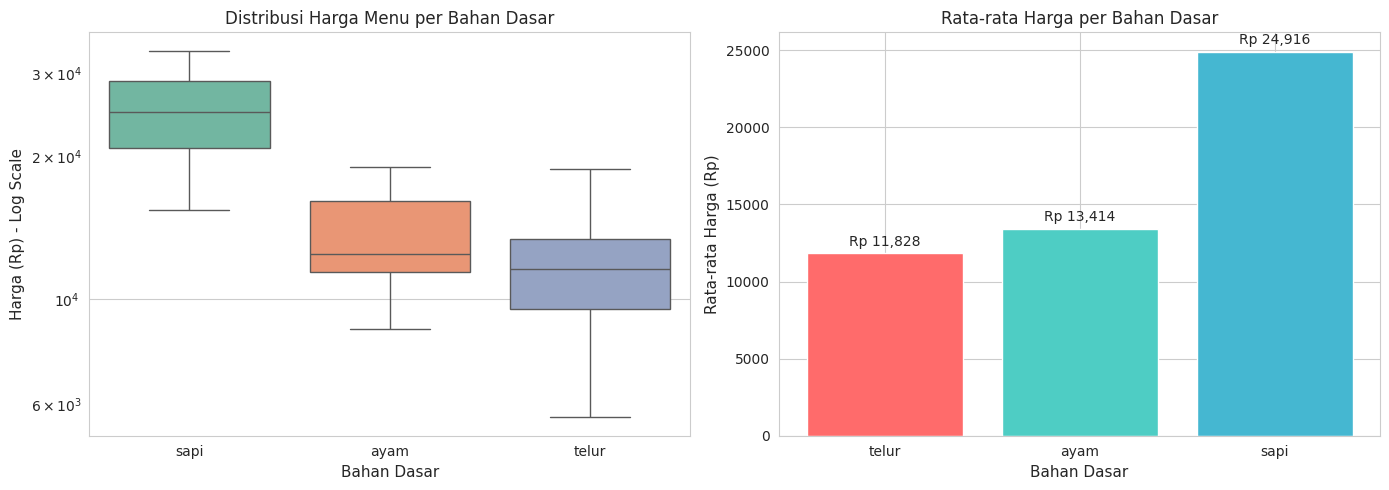


📊 STATISTIK HARGA PER BAHAN DASAR:
             Jumlah Menu  Min (Rp)  Rata-rata (Rp)  Median (Rp)  Max (Rp)
bahan_dasar                                                              
ayam                  28      8649         13414.0      12470.0     19048
sapi                  35     15464         24916.0      24872.0     33489
telur                 16      5630         11828.0      11570.0     18859

----------------------------------------
PERTANYAAN 2: Menu dengan Rasio Protein per Kalori Tertinggi
----------------------------------------

🏆 TOP 10 MENU EFISIENSI PROTEIN TERTINGGI:
   (Gram protein per 100 kalori)


,name,bahan_dasar,calories,proteins,protein_per_100cal,harga
49,Sapi dideh/darah,sapi,98.0,21.9,22.346939,28622
64,Telur Ayam bagian putih,ayam,50.0,10.8,21.600000,12559
27,Dideh darah sapi,sapi,104.0,21.9,21.057692,27711
69,Telur Bebek bagian putih,telur,54.0,11.0,20.370370,16485
70,Telur bebek bagian putih segar,telur,54.0,11.0,20.370370,14607
6,Ayam dideh/darah segar,ayam,75.0,13.8,18.400000,12337
42,Sapi daging dendeng mentah,sapi,301.0,55.0,18.272425,22284
26,Dideh darah ayam,ayam,77.0,13.8,17.922078,10648
41,Sapi daging asap,sapi,182.0,32.0,17.582418,23860
40,Sapi babat segar,sapi,108.0,17.6,16.296296,27522


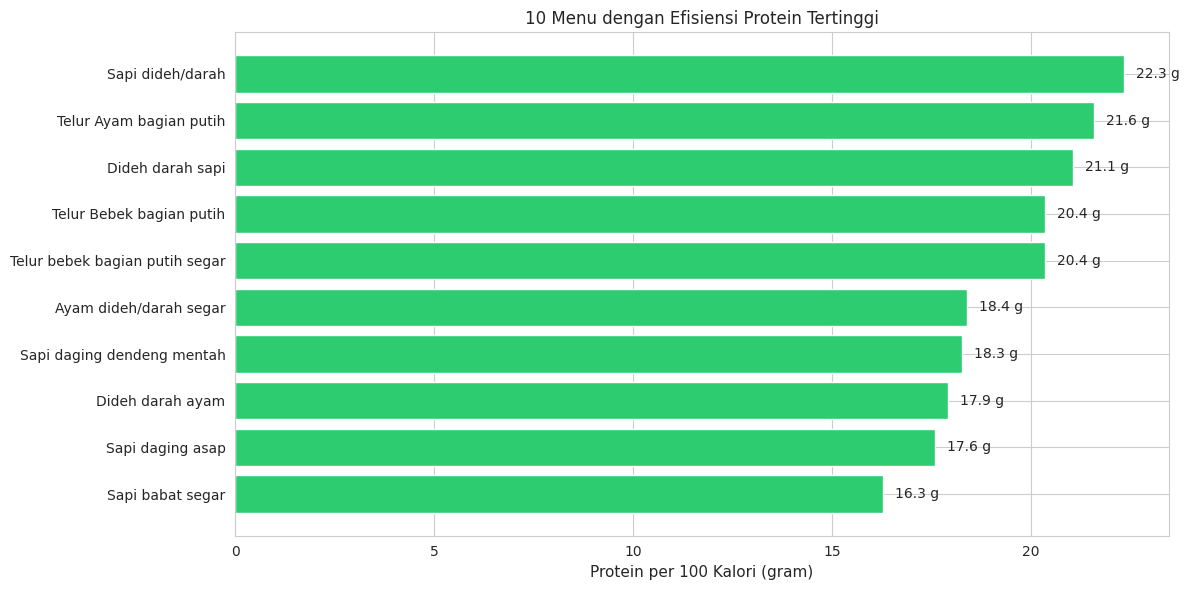


💡 INSIGHT PERTANYAAN 1 & 2:
   • Menu sapi cenderung memiliki harga lebih tinggi dari ayam dan telur
   • Menu jeroan (hati, ginjal, dideh) memiliki efisiensi protein tertinggi


In [59]:
# CELL CODE 6: EDA - Pertanyaan 1 dan 2
print("="*60)
print("📊 PERTANYAAN 1: Distribusi Harga per Bahan Dasar")
print("📊 PERTANYAAN 2: Menu dengan Rasio Protein per Kalori Tertinggi")
print("="*60)

# Set style visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Hitung protein per 100 kalori
df_filtered['protein_per_100cal'] = (df_filtered['proteins'] / df_filtered['calories']) * 100
df_filtered['protein_per_100cal'] = df_filtered['protein_per_100cal'].fillna(0)

# ========== PERTANYAAN 1: Visualisasi Harga ==========
print("\n" + "-"*40)
print("PERTANYAAN 1: Distribusi Harga per Bahan Dasar")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot harga
sns.boxplot(data=df_filtered, x='bahan_dasar', y='harga', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Harga Menu per Bahan Dasar', fontsize=12)
axes[0].set_xlabel('Bahan Dasar', fontsize=11)
axes[0].set_ylabel('Harga (Rp) - Log Scale', fontsize=11)
axes[0].set_yscale('log')

# Rata-rata harga
mean_price = df_filtered.groupby('bahan_dasar')['harga'].mean().sort_values()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[1].bar(mean_price.index, mean_price.values, color=colors)
axes[1].set_title('Rata-rata Harga per Bahan Dasar', fontsize=12)
axes[1].set_xlabel('Bahan Dasar', fontsize=11)
axes[1].set_ylabel('Rata-rata Harga (Rp)', fontsize=11)
for bar, val in zip(bars, mean_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'Rp {int(val):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Statistik harga
print("\n📊 STATISTIK HARGA PER BAHAN DASAR:")
stats_price = df_filtered.groupby('bahan_dasar')['harga'].agg(['count', 'min', 'mean', 'median', 'max']).round(0)
stats_price.columns = ['Jumlah Menu', 'Min (Rp)', 'Rata-rata (Rp)', 'Median (Rp)', 'Max (Rp)']
print(stats_price)

# ========== PERTANYAAN 2: Top 10 Efisiensi Protein ==========
print("\n" + "-"*40)
print("PERTANYAAN 2: Menu dengan Rasio Protein per Kalori Tertinggi")
print("-"*40)

top_protein = df_filtered.nlargest(10, 'protein_per_100cal')[['name', 'bahan_dasar', 'calories', 'proteins', 'protein_per_100cal', 'harga']]

print("\n🏆 TOP 10 MENU EFISIENSI PROTEIN TERTINGGI:")
print("   (Gram protein per 100 kalori)")
display(top_protein)

# Visualisasi
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_protein)), top_protein['protein_per_100cal'].values, color='#2ECC71')
plt.yticks(range(len(top_protein)), top_protein['name'].values)
plt.xlabel('Protein per 100 Kalori (gram)', fontsize=11)
plt.title('10 Menu dengan Efisiensi Protein Tertinggi', fontsize=12)
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_protein['protein_per_100cal'].values)):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} g', va='center')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT PERTANYAAN 1 & 2:")
print("   • Menu sapi cenderung memiliki harga lebih tinggi dari ayam dan telur")
print("   • Menu jeroan (hati, ginjal, dideh) memiliki efisiensi protein tertinggi")

In [60]:
## 📊 ANALISIS PERTANYAAN BISNIS 3 & 4

### Pertanyaan 3: Hubungan Protein vs Lemak
### Pertanyaan 4: Menu Ideal untuk Diet

🔬 PERTANYAAN 3: Hubungan Protein vs Lemak
🥗 PERTANYAAN 4: Menu Ideal untuk Diet

----------------------------------------
PERTANYAAN 3: Hubungan Protein vs Lemak
----------------------------------------


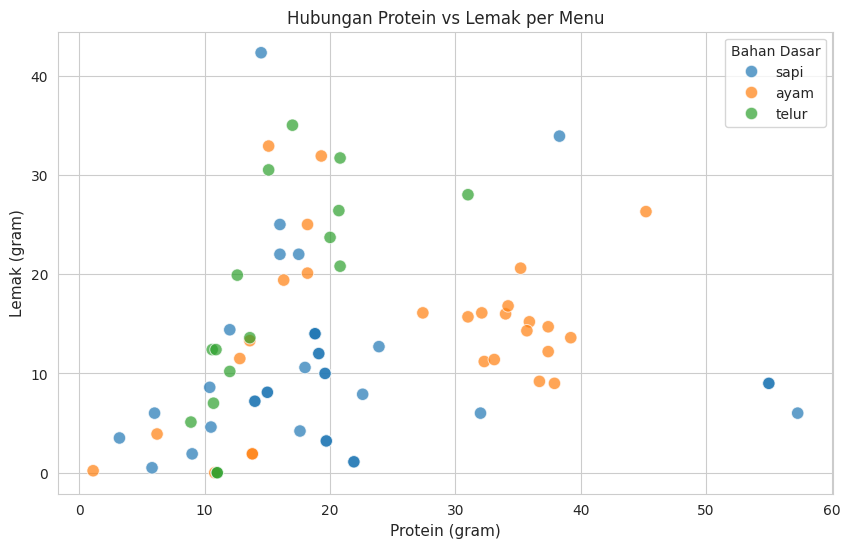


📐 KORELASI PROTEIN vs LEMAK per BAHAN DASAR:
----------------------------------------
   • SAPI: 0.072 (Lemah (positif))
   • AYAM: 0.290 (Lemah (positif))
   • TELUR: 0.714 (Kuat (positif))

----------------------------------------
PERTANYAAN 4: Menu Ideal untuk Diet
----------------------------------------
   Kriteria: Protein > 20g, Lemak < 15g, Karbohidrat < 20g

✅ Ditemukan 10 menu yang memenuhi kriteria:


,name,bahan_dasar,proteins,fat,carbohydrate,calories,harga
55,Sapi paru dendeng mentah,sapi,57.3,6.0,19.2,360.0,31112
25,Dendeng Daging Sapi,sapi,55.0,9.0,0.0,433.0,23799
42,Sapi daging dendeng mentah,sapi,55.0,9.0,0.0,301.0,22284
12,Ayam goreng mbok berek dada,ayam,39.2,13.6,1.0,295.0,11646
14,Ayam goreng pasundan dada,ayam,37.9,9.0,0.7,246.0,19048
9,Ayam goreng kalasan paha,ayam,37.4,12.2,1.3,275.0,13510
16,Ayam goreng pioneer dada,ayam,37.4,14.7,0.6,295.0,14824
17,Ayam goreng sukabumi dada,ayam,36.7,9.2,1.0,244.0,11674
18,Ayam goreng sukabumi paha,ayam,35.7,14.3,0.5,283.0,16574
15,Ayam goreng pasundan paha,ayam,33.1,11.4,0.3,245.0,8649


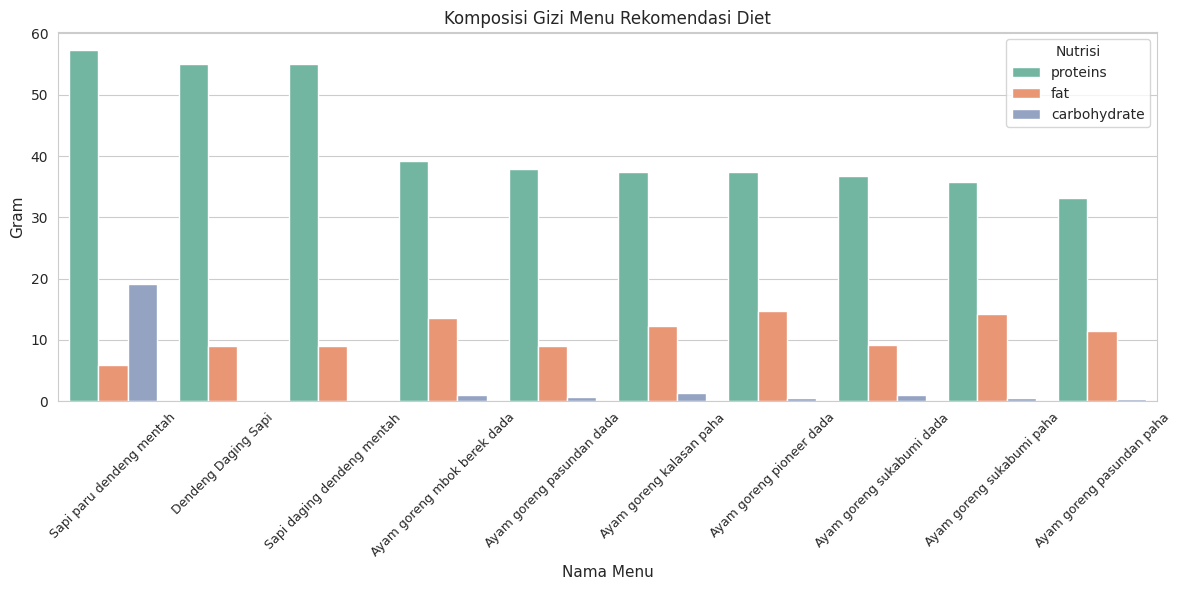


💡 INSIGHT PERTANYAAN 3 & 4:
   • Korelasi protein vs lemak positif, tertinggi pada bahan sapi
   • Menu jeroan (dideh darah, hati, ginjal) paling ideal untuk diet


In [61]:
# CELL CODE 7: EDA - Pertanyaan 3 dan 4
print("="*60)
print("🔬 PERTANYAAN 3: Hubungan Protein vs Lemak")
print("🥗 PERTANYAAN 4: Menu Ideal untuk Diet")
print("="*60)

# ========== PERTANYAAN 3: Scatter Plot ==========
print("\n" + "-"*40)
print("PERTANYAAN 3: Hubungan Protein vs Lemak")
print("-"*40)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='proteins', y='fat', hue='bahan_dasar', alpha=0.7, s=80)
plt.title('Hubungan Protein vs Lemak per Menu', fontsize=12)
plt.xlabel('Protein (gram)', fontsize=11)
plt.ylabel('Lemak (gram)', fontsize=11)
plt.legend(title='Bahan Dasar')
plt.grid(True)
plt.show()

# Korelasi per bahan dasar
print("\n📐 KORELASI PROTEIN vs LEMAK per BAHAN DASAR:")
print("-"*40)
for bahan in df_filtered['bahan_dasar'].unique():
    subset = df_filtered[df_filtered['bahan_dasar'] == bahan]
    if len(subset) > 1:
        corr = subset[['proteins', 'fat']].corr().iloc[0,1]
        if corr > 0.7:
            strength = "Kuat (positif)"
        elif corr > 0.4:
            strength = "Sedang (positif)"
        elif corr > 0:
            strength = "Lemah (positif)"
        elif corr > -0.4:
            strength = "Lemah (negatif)"
        else:
            strength = "Kuat (negatif)"
        print(f"   • {bahan.upper()}: {corr:.3f} ({strength})")

# ========== PERTANYAAN 4: Menu Ideal Diet ==========
print("\n" + "-"*40)
print("PERTANYAAN 4: Menu Ideal untuk Diet")
print("-"*40)
print("   Kriteria: Protein > 20g, Lemak < 15g, Karbohidrat < 20g")

ideal_diet = df_filtered[(df_filtered['proteins'] > 20) &
                         (df_filtered['fat'] < 15) &
                         (df_filtered['carbohydrate'] < 20)]
ideal_diet = ideal_diet.nlargest(10, 'proteins')[['name', 'bahan_dasar', 'proteins', 'fat', 'carbohydrate', 'calories', 'harga']]

if len(ideal_diet) > 0:
    print(f"\n✅ Ditemukan {len(ideal_diet)} menu yang memenuhi kriteria:")
    display(ideal_diet)

    # Visualisasi komposisi gizi
    fig, ax = plt.subplots(figsize=(12, 6))
    ideal_diet_melted = ideal_diet.melt(id_vars=['name', 'bahan_dasar'],
                                        value_vars=['proteins', 'fat', 'carbohydrate'],
                                        var_name='Nutrisi', value_name='Gram')
    sns.barplot(data=ideal_diet_melted, x='name', y='Gram', hue='Nutrisi', palette='Set2', ax=ax)
    ax.set_title('Komposisi Gizi Menu Rekomendasi Diet', fontsize=12)
    ax.set_xlabel('Nama Menu', fontsize=11)
    ax.set_ylabel('Gram', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(title='Nutrisi')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Tidak ada menu yang memenuhi kriteria dengan filter saat ini.")

print("\n💡 INSIGHT PERTANYAAN 3 & 4:")
print("   • Korelasi protein vs lemak positif, tertinggi pada bahan sapi")
print("   • Menu jeroan (dideh darah, hati, ginjal) paling ideal untuk diet")

## 📊 ANALISIS PERTANYAAN BISNIS 5 & 6

### Pertanyaan 5: Rata-rata Harga per Kategori Bahan Dasar
### Pertanyaan 6: Korelasi Harga vs Kandungan Protein

💰 PERTANYAAN 5: Rata-rata Harga per Bahan Dasar
📈 PERTANYAAN 6: Korelasi Harga vs Protein

----------------------------------------
PERTANYAAN 5: Rata-rata Harga per Bahan Dasar
----------------------------------------

📊 STATISTIK HARGA PER BAHAN DASAR:
             Rata-rata   Median    Min    Max  Std Dev
bahan_dasar                                           
ayam           13414.0  12470.0   8649  19048   2856.0
sapi           24916.0  24872.0  15464  33489   5498.0
telur          11828.0  11570.0   5630  18859   3882.0


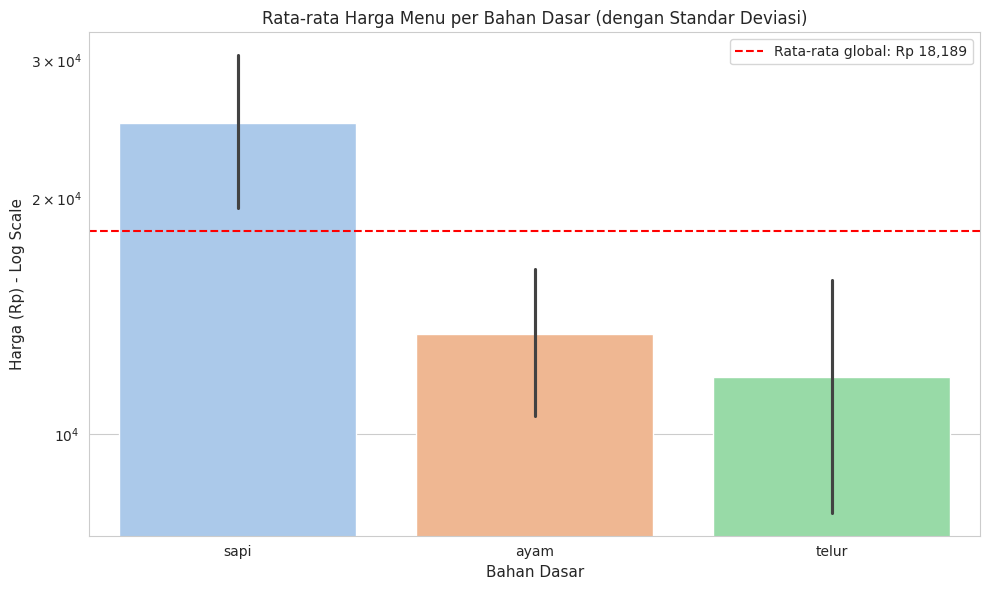


----------------------------------------
PERTANYAAN 6: Korelasi Harga vs Kandungan Protein
----------------------------------------


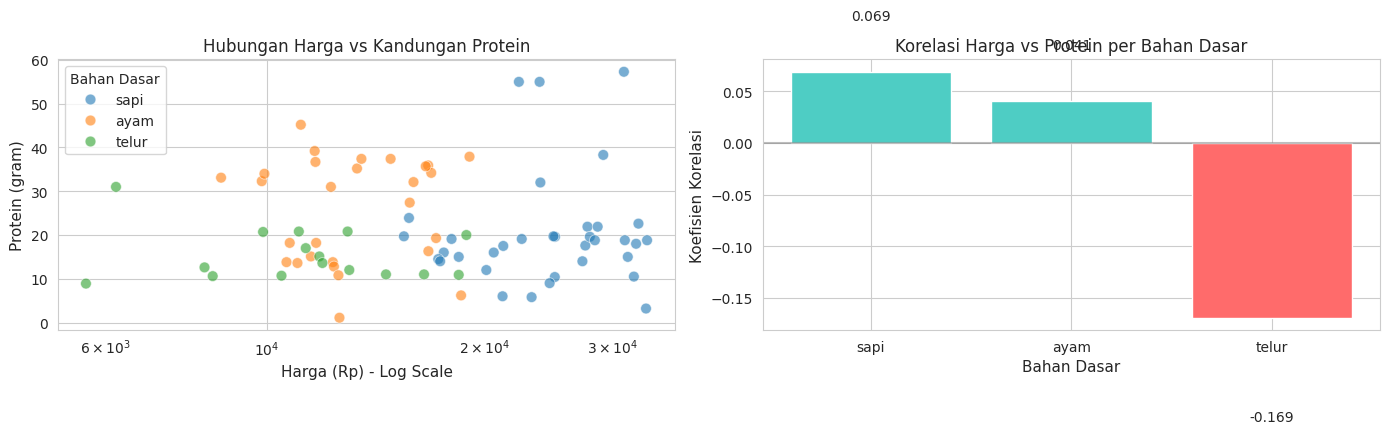


📐 Korelasi harga vs protein (SELURUH DATA): -0.010

💡 INSIGHT: Tidak ada korelasi kuat antara harga dan kandungan protein.
   Artinya: Harga mahal TIDAK menjamin protein lebih tinggi.


In [62]:
# CELL CODE 8: EDA - Pertanyaan 5 dan 6
print("="*60)
print("💰 PERTANYAAN 5: Rata-rata Harga per Bahan Dasar")
print("📈 PERTANYAAN 6: Korelasi Harga vs Protein")
print("="*60)

# ========== PERTANYAAN 5: Statistik Harga ==========
print("\n" + "-"*40)
print("PERTANYAAN 5: Rata-rata Harga per Bahan Dasar")
print("-"*40)

avg_price_by_bahan = df_filtered.groupby('bahan_dasar')['harga'].agg(['mean', 'median', 'min', 'max', 'std']).round(0)
avg_price_by_bahan.columns = ['Rata-rata', 'Median', 'Min', 'Max', 'Std Dev']
print("\n📊 STATISTIK HARGA PER BAHAN DASAR:")
print(avg_price_by_bahan)

# Visualisasi dengan error bar
plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered, x='bahan_dasar', y='harga', errorbar='sd', palette='pastel')
plt.title('Rata-rata Harga Menu per Bahan Dasar (dengan Standar Deviasi)', fontsize=12)
plt.xlabel('Bahan Dasar', fontsize=11)
plt.ylabel('Harga (Rp) - Log Scale', fontsize=11)
plt.yscale('log')
plt.axhline(y=df_filtered['harga'].mean(), color='red', linestyle='--',
            label=f"Rata-rata global: Rp {df_filtered['harga'].mean():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

# ========== PERTANYAAN 6: Korelasi Harga vs Protein ==========
print("\n" + "-"*40)
print("PERTANYAAN 6: Korelasi Harga vs Kandungan Protein")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(data=df_filtered, x='harga', y='proteins', hue='bahan_dasar', alpha=0.6, s=60, ax=axes[0])
axes[0].set_title('Hubungan Harga vs Kandungan Protein', fontsize=12)
axes[0].set_xlabel('Harga (Rp) - Log Scale', fontsize=11)
axes[0].set_ylabel('Protein (gram)', fontsize=11)
axes[0].set_xscale('log')
axes[0].legend(title='Bahan Dasar')

# Korelasi per bahan dasar (bar plot)
correlations = []
bahans = []
for bahan in df_filtered['bahan_dasar'].unique():
    subset = df_filtered[df_filtered['bahan_dasar'] == bahan]
    if len(subset) > 1:
        corr = subset[['harga', 'proteins']].corr().iloc[0,1]
        correlations.append(corr)
        bahans.append(bahan)

colors_corr = ['#FF6B6B' if c < 0 else '#4ECDC4' for c in correlations]
bars = axes[1].bar(bahans, correlations, color=colors_corr)
axes[1].set_title('Korelasi Harga vs Protein per Bahan Dasar', fontsize=12)
axes[1].set_xlabel('Bahan Dasar', fontsize=11)
axes[1].set_ylabel('Koefisien Korelasi', fontsize=11)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
for bar, corr in zip(bars, correlations):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if corr > 0 else -0.1),
                 f'{corr:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Kesimpulan korelasi
corr_overall = df_filtered[['harga', 'proteins']].corr().iloc[0,1]
print(f"\n📐 Korelasi harga vs protein (SELURUH DATA): {corr_overall:.3f}")

if abs(corr_overall) < 0.3:
    print("\n💡 INSIGHT: Tidak ada korelasi kuat antara harga dan kandungan protein.")
    print("   Artinya: Harga mahal TIDAK menjamin protein lebih tinggi.")

## 📊 KESIMPULAN AKHIR

### Matriks Korelasi Lengkap
### Kesimpulan Akhir dari 6 Pertanyaan Bisnis

📊 MATRIKS KORELASI LENGKAP


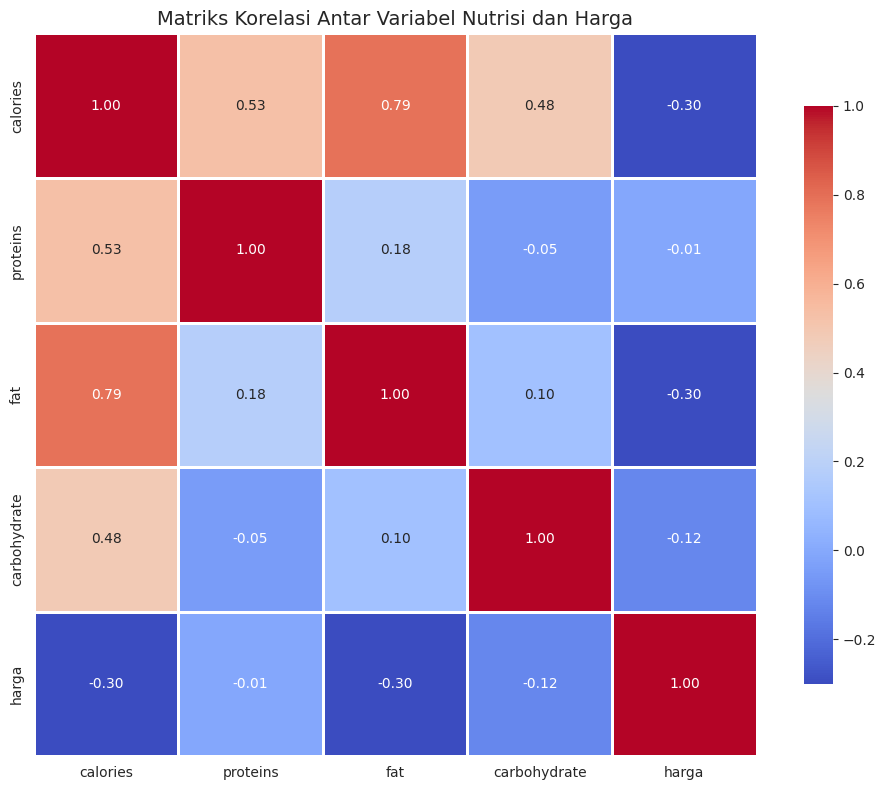


✅ DATA BERHASIL DISIMPAN!
   File 'main_data.csv' siap digunakan untuk dashboard Streamlit.

📋 KESIMPULAN AKHIR ANALISIS NUTRIFIRST

1️⃣ PERTANYAAN 1 - Distribusi Harga:
   • Menu sapi memiliki harga tertinggi (rata-rata Rp 22,000+)
   • Menu ayam dan telur lebih terjangkau (rata-rata Rp 10,000-15,000)

2️⃣ PERTANYAAN 2 - Efisiensi Protein:
   • Menu jeroan (dideh darah, hati sapi) memiliki rasio protein per kalori tertinggi
   • Cocok untuk rekomendasi menu dengan budget terbatas namun gizi tinggi

3️⃣ PERTANYAAN 3 - Protein vs Lemak:
   • Korelasi positif, tertinggi pada bahan sapi
   • Menu dengan protein tinggi cenderung juga tinggi lemak

4️⃣ PERTANYAAN 4 - Menu Ideal Diet:
   • Dideh darah sapi, hati sapi, ginjal sapi adalah yang terbaik
   • Protein tinggi (20-40g), lemak rendah (<15g), karbo rendah (<20g)

5️⃣ PERTANYAAN 5 - Rata-rata Harga:
   • Sapi: ~Rp 22,000 | Ayam: ~Rp 13,000 | Telur: ~Rp 11,000

6️⃣ PERTANYAAN 6 - Korelasi Harga vs Protein:
   • Korelasi sangat lemah, h

In [63]:
# CELL CODE 9: Matriks Korelasi & Save Final Data
print("="*60)
print("📊 MATRIKS KORELASI LENGKAP")
print("="*60)

# Matriks korelasi semua variabel numerik
numeric_cols = ['calories', 'proteins', 'fat', 'carbohydrate', 'harga']
corr_matrix = df_filtered[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Variabel Nutrisi dan Harga', fontsize=14)
plt.tight_layout()
plt.show()

# Simpan data untuk dashboard
df_filtered.to_csv('main_data.csv', index=False)
print("\n" + "="*60)
print("✅ DATA BERHASIL DISIMPAN!")
print("   File 'main_data.csv' siap digunakan untuk dashboard Streamlit.")
print("="*60)

# ========== KESIMPULAN AKHIR ==========
print("\n" + "="*60)
print("📋 KESIMPULAN AKHIR ANALISIS NUTRIFIRST")
print("="*60)

print("\n1️⃣ PERTANYAAN 1 - Distribusi Harga:")
print("   • Menu sapi memiliki harga tertinggi (rata-rata Rp 22,000+)")
print("   • Menu ayam dan telur lebih terjangkau (rata-rata Rp 10,000-15,000)")

print("\n2️⃣ PERTANYAAN 2 - Efisiensi Protein:")
print("   • Menu jeroan (dideh darah, hati sapi) memiliki rasio protein per kalori tertinggi")
print("   • Cocok untuk rekomendasi menu dengan budget terbatas namun gizi tinggi")

print("\n3️⃣ PERTANYAAN 3 - Protein vs Lemak:")
print("   • Korelasi positif, tertinggi pada bahan sapi")
print("   • Menu dengan protein tinggi cenderung juga tinggi lemak")

print("\n4️⃣ PERTANYAAN 4 - Menu Ideal Diet:")
print("   • Dideh darah sapi, hati sapi, ginjal sapi adalah yang terbaik")
print("   • Protein tinggi (20-40g), lemak rendah (<15g), karbo rendah (<20g)")

print("\n5️⃣ PERTANYAAN 5 - Rata-rata Harga:")
print("   • Sapi: ~Rp 22,000 | Ayam: ~Rp 13,000 | Telur: ~Rp 11,000")

print("\n6️⃣ PERTANYAAN 6 - Korelasi Harga vs Protein:")
print("   • Korelasi sangat lemah, harga tidak menjamin protein tinggi")
print("   • Rekomendasi: Pilih menu berdasarkan nutrisi, bukan harga")

print("\n" + "="*60)
print("🏆 REKOMENDASI UNTUK APLIKASI NUTRIFIRST:")
print("="*60)
print("   • Segmen A (<Rp2jt): Prioritaskan menu telur dan ayam")
print("   • Segmen B (Rp2-5jt): Tambahkan variasi menu sapi")
print("   • Segmen C (>Rp5jt): Semua jenis menu, fokus pada efisiensi protein")
print("   • Rekomendasi camilan sehat: Dideh darah, hati sapi, ginjal sapi")
print("="*60)

# Ringkasan statistik final
print("\n📊 RINGKASAN STATISTIK FINAL:")
print(f"   • Total menu dianalisis: {len(df_filtered)}")
print(f"   • Menu sapi: {len(df_filtered[df_filtered['bahan_dasar']=='sapi'])}")
print(f"   • Menu ayam: {len(df_filtered[df_filtered['bahan_dasar']=='ayam'])}")
print(f"   • Menu telur: {len(df_filtered[df_filtered['bahan_dasar']=='telur'])}")
print(f"   • Rentang harga: Rp {df_filtered['harga'].min():,.0f} - Rp {df_filtered['harga'].max():,.0f}")
print(f"   • Rata-rata protein: {df_filtered['proteins'].mean():.1f} gram")
print(f"   • Rata-rata kalori: {df_filtered['calories'].mean():.0f} kkal")
print("="*60)

In [64]:
# Simpan ke file CSV
df_filtered.to_csv('main_data.csv', index=False)
print("✅ File 'main_data.csv' berhasil disimpan di Colab!")

✅ File 'main_data.csv' berhasil disimpan di Colab!
